In [58]:
import pandas as pd
import numpy as np
import statsmodels.api as sm 
import statsmodels.formula.api as smf
import scipy.stats as stats
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA


In [59]:
df = pd.read_csv('ca_county_schools_final.csv')
df.head()

,County Code,County Name,pct_met_ELA,pct_met_Math,frpm_pct_free,COUNTYFIP_3,median_income,poverty_rate,pct_bachelors_plus,pct_foodstmp,homeownership_rate,median_house_value,pct_welfare
0,1,Alameda,56.16,48.15,40.91,1,193855.427932,0.103755,0.384415,0.104060,0.570250,1.130251e+06,0.021909
1,4,Butte,46.38,33.23,54.39,7,109947.537301,0.179910,0.223573,0.177883,0.593828,4.822655e+05,0.024478
2,7,Contra Costa,51.98,42.02,38.35,13,189351.205012,0.083536,0.327224,0.100044,0.679501,9.903505e+05,0.014255
3,9,El Dorado,57.75,46.07,28.91,17,165400.949140,0.086965,0.292535,0.067082,0.772462,7.493431e+05,0.014498
4,10,Fresno,46.44,34.09,60.99,19,105361.665528,0.188770,0.156259,0.253679,0.561870,4.381867e+05,0.028745


In [60]:
#Code from lecture 
def add(df, selected_columns, columns, criterion, response='y'):
    best_criterion = np.inf
    best_column = None
    for column in columns - selected_columns:
        new_columns = selected_columns.union({column})
        formula = f'{response} ~ {" + ".join(new_columns)}'
        current_criterion = criterion(formula, df)
        if current_criterion < best_criterion:
            best_criterion = current_criterion
            best_column = column
    return selected_columns.union({best_column}), best_criterion

def forward(df, criterion, response='y'):
    selected_columns = set()
    columns = set(df.columns.drop(response))
    best_criterion = np.inf
    while len(selected_columns) < len(columns):
        potential_columns, current_criterion = add(df, selected_columns, columns, criterion, response)
        if current_criterion > best_criterion:
            break
        else:
            selected_columns = potential_columns
            best_criterion = current_criterion
            print(f'Criterion: {best_criterion}')
    return selected_columns

ELA: Stepwise Selection

In [61]:
trainingDf = df[['COUNTYFIP_3','frpm_pct_free','median_income','poverty_rate','pct_bachelors_plus','pct_met_ELA','pct_foodstmp','homeownership_rate','median_house_value','pct_welfare']]

r2_adj_criterion = lambda formula, df: -smf.ols(formula, data=df).fit().rsquared_adj
bic_criterion = lambda formula, df: smf.ols(formula, data=df).fit().bic
aic_criterion = lambda formula, df: smf.ols(formula, data=df).fit().aic

forward_vars_aic = forward(trainingDf, aic_criterion, response='pct_met_ELA')
forward_vars_bic = forward(trainingDf, bic_criterion, response='pct_met_ELA')
forward_vars_r2 = forward(trainingDf, r2_adj_criterion, response='pct_met_ELA')

print(f'forward_vars_aic: {forward_vars_aic}')
print(f'forward_vars_bic: {forward_vars_bic}')
print(f'forward_vars_r2: {forward_vars_r2}')

Criterion: 193.5287964574923
Criterion: 190.39856666764544
Criterion: 186.793988575933
Criterion: 196.58151750672462
Criterion: 194.9776482414939
Criterion: 192.89943067439765
Criterion: -0.6894056404576936
Criterion: -0.7242906206665798
Criterion: -0.7583968199976736
forward_vars_aic: {'pct_bachelors_plus', 'pct_welfare', 'frpm_pct_free'}
forward_vars_bic: {'pct_bachelors_plus', 'pct_welfare', 'frpm_pct_free'}
forward_vars_r2: {'pct_bachelors_plus', 'pct_welfare', 'frpm_pct_free'}


Math: Stepwise Selection

In [62]:
trainingDf = df[['COUNTYFIP_3','frpm_pct_free','median_income','poverty_rate','pct_bachelors_plus','pct_met_Math','pct_foodstmp','homeownership_rate','median_house_value','pct_welfare']]

r2_adj_criterion = lambda formula, df: -smf.ols(formula, data=df).fit().rsquared_adj
bic_criterion = lambda formula, df: smf.ols(formula, data=df).fit().bic
aic_criterion = lambda formula, df: smf.ols(formula, data=df).fit().aic

forward_vars_aic = forward(trainingDf, aic_criterion, response='pct_met_Math')
forward_vars_bic = forward(trainingDf, bic_criterion, response='pct_met_Math')
forward_vars_r2 = forward(trainingDf, r2_adj_criterion, response='pct_met_Math')

print(f'forward_vars_aic: {forward_vars_aic}')
print(f'forward_vars_bic: {forward_vars_bic}')
print(f'forward_vars_r2: {forward_vars_r2}')

Criterion: 204.01675398703748
Criterion: 196.053504245497
Criterion: 189.3111010917418
Criterion: 207.0694750362698
Criterion: 200.63258581934548
Criterion: 195.41654319020643
Criterion: -0.7240207341322111
Criterion: -0.7874796644613641
Criterion: -0.8301869716186766
Criterion: -0.8312985633164826
Criterion: -0.8348045595261658
forward_vars_aic: {'pct_bachelors_plus', 'pct_welfare', 'frpm_pct_free'}
forward_vars_bic: {'pct_bachelors_plus', 'pct_welfare', 'frpm_pct_free'}
forward_vars_r2: {'pct_welfare', 'pct_bachelors_plus', 'median_house_value', 'frpm_pct_free', 'median_income'}


ELA Lasso

<Axes: >

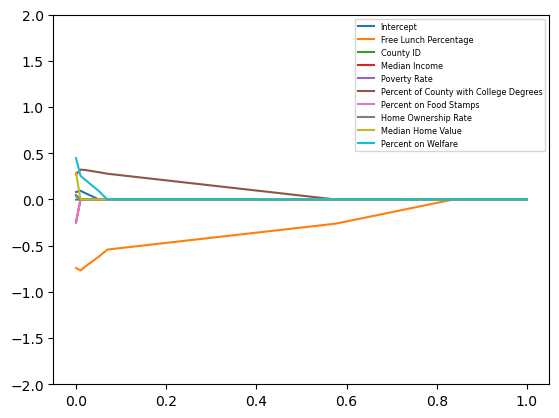

In [63]:
fullModelFormula = 'pct_met_ELA ~ ' + '+'.join(df.columns.drop(['pct_met_ELA','pct_met_Math','County Code','County Name']))

from sklearn.preprocessing import StandardScaler

cols_to_standardize = ['pct_met_ELA', 'pct_met_Math', 'frpm_pct_free','median_income','poverty_rate','pct_bachelors_plus','pct_met_ELA','pct_foodstmp','homeownership_rate','median_house_value','pct_welfare']

scaler = StandardScaler()
df[cols_to_standardize] = scaler.fit_transform(df[cols_to_standardize])

lambdas = np.arange(0,1.01,.01)
coef = []
for lam in lambdas:
    coef.append(smf.ols( fullModelFormula,df).fit_regularized(alpha = lam,L1_wt = 1).params)

nameMap = {'frpm_pct_free': 'Free Lunch Percentage', 
            'COUNTYFIP_3': 'County ID',
            'median_income':'Median Income',
            'poverty_rate': 'Poverty Rate',
            'pct_bachelors_plus': "Percent of County with College Degrees",
            'pct_foodstmp': 'Percent on Food Stamps',
            'homeownership_rate': 'Home Ownership Rate',
            'median_house_value': 'Median Home Value',
            'pct_welfare':'Percent on Welfare'
            
                                                 }
ax = pd.DataFrame(coef, lambdas).rename(columns=nameMap).plot(kind='line',ylim=(-2,2))
ax.legend(loc='upper right', fontsize='xx-small')
ax

Math Lasso

<Axes: >

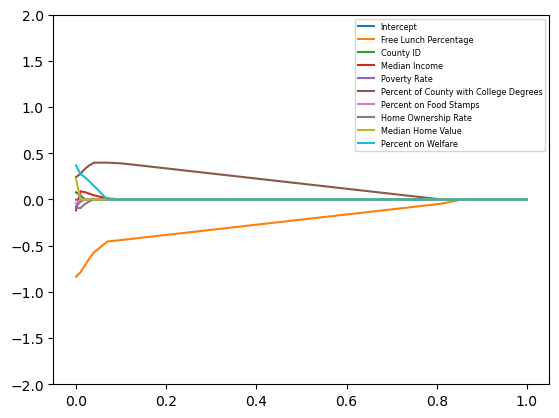

In [64]:
fullModelFormula = 'pct_met_Math ~ ' + '+'.join(df.columns.drop(['pct_met_ELA','pct_met_Math','County Code','County Name']))

from sklearn.preprocessing import StandardScaler

cols_to_standardize = ['pct_met_ELA', 'pct_met_Math', 'frpm_pct_free','median_income','poverty_rate','pct_bachelors_plus','pct_met_ELA','pct_foodstmp','homeownership_rate','median_house_value','pct_welfare']

scaler = StandardScaler()
df[cols_to_standardize] = scaler.fit_transform(df[cols_to_standardize])

lambdas = np.arange(0,1.01,.01)
coef = []
for lam in lambdas:
    coef.append(smf.ols( fullModelFormula,df).fit_regularized(alpha = lam,L1_wt = 1).params)

nameMap = {'frpm_pct_free': 'Free Lunch Percentage', 
            'COUNTYFIP_3': 'County ID',
            'median_income':'Median Income',
            'poverty_rate': 'Poverty Rate',
            'pct_bachelors_plus': "Percent of County with College Degrees",
            'pct_foodstmp': 'Percent on Food Stamps',
            'homeownership_rate': 'Home Ownership Rate',
            'median_house_value': 'Median Home Value',
            'pct_welfare':'Percent on Welfare'
            
                                                 }
ax = pd.DataFrame(coef, lambdas).rename(columns=nameMap).plot(kind='line',ylim=(-2,2))
ax.legend(loc='upper right', fontsize='xx-small')
ax

Principal Component Analysis

In [65]:
pca = PCA(n_components=0.95)
x_transform = pca.fit_transform(df[['frpm_pct_free','median_income','poverty_rate','pct_bachelors_plus','pct_foodstmp','homeownership_rate','median_house_value','pct_welfare']])
pcaWeights = pd.DataFrame(
    pca.components_.T,
    index=['frpm_pct_free','median_income','poverty_rate','pct_bachelors_plus','pct_foodstmp','homeownership_rate','median_house_value','pct_welfare'],
    columns=['PC1','PC2','PC3','PC4']
)
pcaWeights

,PC1,PC2,PC3,PC4
frpm_pct_free,0.385942,-0.157063,-0.150121,-0.482935
median_income,-0.386894,-0.235048,0.317833,-0.049898
poverty_rate,0.362749,-0.212400,-0.144249,0.801346
pct_bachelors_plus,-0.376987,-0.289276,0.161136,0.285086
pct_foodstmp,0.392768,-0.100823,0.300396,-0.087463
homeownership_rate,-0.120988,0.779891,0.369551,0.150518
median_house_value,-0.363779,-0.374168,0.139788,-0.102677
pct_welfare,0.355551,-0.181362,0.763759,-0.002593


ANOVA: Comparing the full model to subsets of the model to get the model with the fewest predictors which is still similar to the full model

ELA

In [66]:
from itertools import combinations
from statsmodels.stats.anova import anova_lm

formulas = []
features = set(df.columns.drop(['pct_met_ELA','pct_met_Math','County Code','County Name']))
for i in range(1,16):
    for combo in combinations(features,i):
        formula = 'pct_met_ELA ~' + '+'.join(combo)
        formulas.append(formula)

fullModel = smf.ols(formulas[-1], df).fit()
results = []
for f in formulas[:-1]:
    reduced = smf.ols(f, df).fit()
    anovaResult = anova_lm(reduced, fullModel)
    results.append({
        'formula': f,
        'p_value': anovaResult['Pr(>F)'].iloc[1],
    })



results = pd.DataFrame(results).sort_values('p_value').reset_index(drop=True)

def n_terms(formula):
    rhs = formula.split('~')[1]
    return len([t for t in rhs.split('+') if t.strip() not in ('1', '')])

results['n_terms'] = results['formula'].apply(n_terms)

adequate = results[results['p_value'] > 0.05]          # not sig. different from full
smallest_adequate = adequate.sort_values('n_terms').iloc[0]
print(smallest_adequate['formula'])

pct_met_ELA ~frpm_pct_free


In [67]:
print(fullModel.summary())
reduced = smf.ols('pct_met_ELA ~frpm_pct_free', df).fit()
print(reduced.summary())

                            OLS Regression Results                            
Dep. Variable:            pct_met_ELA   R-squared:                       0.804
Model:                            OLS   Adj. R-squared:                  0.730
Method:                 Least Squares   F-statistic:                     10.91
Date:                Thu, 04 Jun 2026   Prob (F-statistic):           1.53e-06
Time:                        12:23:00   Log-Likelihood:                -20.579
No. Observations:                  34   AIC:                             61.16
Df Residuals:                      24   BIC:                             76.42
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              0.0381      0

Math

In [68]:
from itertools import combinations
from statsmodels.stats.anova import anova_lm

formulas = []
features = set(df.columns.drop(['pct_met_ELA','pct_met_Math','County Code','County Name']))
for i in range(1,16):
    for combo in combinations(features,i):
        formula = 'pct_met_Math ~' + '+'.join(combo)
        formulas.append(formula)

fullModel = smf.ols(formulas[-1], df).fit()
results = []
for f in formulas[:-1]:
    reduced = smf.ols(f, df).fit()
    anovaResult = anova_lm(reduced, fullModel)
    results.append({
        'formula': f,
        'p_value': anovaResult['Pr(>F)'].iloc[1],
    })



results = pd.DataFrame(results).sort_values('p_value').reset_index(drop=True)

def n_terms(formula):
    rhs = formula.split('~')[1]
    return len([t for t in rhs.split('+') if t.strip() not in ('1', '')])

results['n_terms'] = results['formula'].apply(n_terms)

adequate = results[results['p_value'] > 0.05]          # not sig. different from full
smallest_adequate = adequate.sort_values('n_terms').iloc[0]
print(smallest_adequate['formula'])

pct_met_Math ~frpm_pct_free+pct_welfare


In [69]:
print(fullModel.summary())
reduced = smf.ols('pct_met_Math ~frpm_pct_free+pct_welfare', df).fit()
print(reduced.summary())

                            OLS Regression Results                            
Dep. Variable:           pct_met_Math   R-squared:                       0.862
Model:                            OLS   Adj. R-squared:                  0.810
Method:                 Least Squares   F-statistic:                     16.61
Date:                Thu, 04 Jun 2026   Prob (F-statistic):           2.84e-08
Time:                        12:23:10   Log-Likelihood:                -14.620
No. Observations:                  34   AIC:                             49.24
Df Residuals:                      24   BIC:                             64.50
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              0.0425      0

,pct_bachelors_plus, pct_welfare seem to be the strongest variables